<a href="https://colab.research.google.com/github/2107163077-prog/my-first-web-app/blob/main/Pharmacoinformatics_5_0_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 薬学インフォマティクス第5回 <ゲノム配列解析> No. 0

2026.05.07 Kawaguchi RK.

* 内容： pytorchの基本
* 目標： pytorchでのニューラルネットワーク学習の流れを理解する
* リンク： https://github.com/carushi/cb_lab/tree/main/code_collection/2026_pharmacoinformatics/No5

## 参考図書
* Pytorch 自然言語処理プログラミング (新納浩幸)

## Google colab用コード

In [39]:
!pip install torch pandas seaborn tqdm matplotlib

## Import packages

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

## Preapre the datasets
* iris dataset
* predict iris type (setosa, versicolor, and vernicia)

In [41]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = datasets.load_iris()
print(iris.DESCR)
print(iris.data.shape)
print(iris.target)
xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, test_size=0.5)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [42]:
xtrain = torch.from_numpy(xtrain).type('torch.FloatTensor')
ytrain = torch.from_numpy(ytrain).type('torch.LongTensor')
xtest = torch.from_numpy(xtest).type('torch.FloatTensor')
ytest = torch.from_numpy(ytest).type('torch.LongTensor')

## Model

In [43]:
class MyIris(nn.Module):
    def __init__(self):
        super(MyIris, self).__init__()
        self.l1 = nn.Linear(4,6)
        self.l2 = nn.Linear(6,6)
        self.l3 = nn.Linear(6,3)

    def forward(self, x):
        h1 = torch.sigmoid(self.l1(x))
        h2 = self.l2(h1)
        h3 = self.l3(h2)
        return h3


## Training setting

In [44]:
model = MyIris()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [45]:
criterion = nn.CrossEntropyLoss()

## Training process

iter: 0 -> 1.115797758102417
iter: 50 -> 1.0222258567810059
iter: 100 -> 0.674738347530365
iter: 150 -> 0.4512459337711334
iter: 200 -> 0.3528662323951721
iter: 250 -> 0.25502821803092957
iter: 300 -> 0.18247726559638977
iter: 350 -> 0.16773168742656708
iter: 400 -> 0.14771707355976105
iter: 450 -> 0.11644367128610611
iter: 500 -> 0.08291010558605194
iter: 550 -> 0.07827509194612503
iter: 600 -> 0.06519840657711029
iter: 650 -> 0.058521781116724014
iter: 700 -> 0.05332508310675621
iter: 750 -> 0.04911601543426514
iter: 800 -> 0.06457487493753433
iter: 850 -> 0.0485101193189621
iter: 900 -> 0.04229835793375969
iter: 950 -> 0.03947475925087929


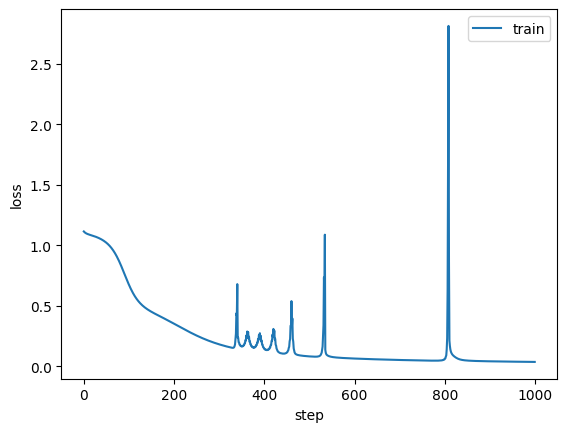

CPU times: user 1.13 s, sys: 3.29 ms, total: 1.14 s
Wall time: 1.4 s


In [46]:
%%time
model.train()
# TODO: lossを保存するリスト・アレイを定義
list_loss = []
for i in range(1000):
    output = model(xtrain)
    loss = criterion(output, ytrain)
    if i%50 == 0:
        print('iter:', i, '->', loss.item())
    # TODO: lossを保存する
    list_loss.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    import matplotlib.pyplot as plt

plt.plot(range(len(list_loss)),list_loss, label="train")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

In [47]:
torch.save(model.state_dict(), 'myiris.model')
model.load_state_dict(torch.load('myiris.model'))

<All keys matched successfully>

## Output

In [48]:
model.eval()
# no grad is required to compute the test dataset without optimization
with torch.no_grad():
    output1 = model(xtest)
    ans = torch.argmax(output1, 1) # 0, 1, 2 for each
    accuracy_all = ((ytest == ans).sum().float() / len(ans)).item()
    print(accuracy_all)

0.9733333587646484


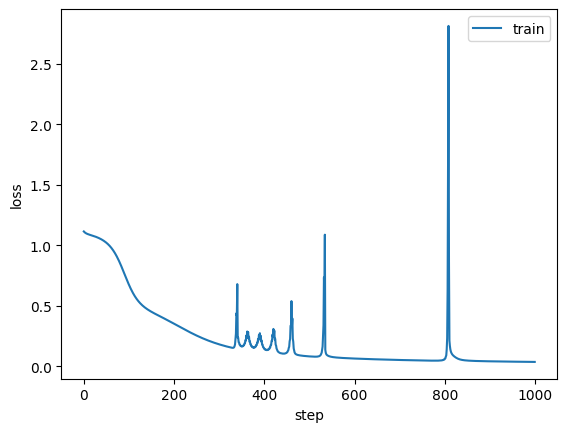

In [49]:
# TODO: 可視化コード
# ヒント: 訓練ロスをグラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する
import matplotlib.pyplot as plt

plt.plot(range(len(list_loss)),list_loss, label="train")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

## Batch computation

In [50]:
%%time
model = MyIris()
optimizer = optim.SGD(model.parameters(), lr=0.1)
n = 75 # data size
bs = 25 # batch size
model.train()
list_loss1 = []
# TODO: lossを保存するリスト・アレイを定義
for i in range(1000):
    idx = np.random.permutation(n)
    for j in range(0, n, bs):
        xtm = xtrain[idx[j:min(j+bs, n)]]
        ytm = ytrain[idx[j:min(j+bs, n)]]
        output = model(xtm)
        loss = criterion(output, ytm)
        if i%50 == 0:
            print('iter:', i, 'batch:', j, '->', loss.item())
        # TODO: loss.item()を保存する
        list_loss1.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

iter: 0 batch: 0 -> 1.0258662700653076
iter: 0 batch: 25 -> 1.1067384481430054
iter: 0 batch: 50 -> 1.0900731086730957
iter: 50 batch: 0 -> 0.4288438856601715
iter: 50 batch: 25 -> 0.38801974058151245
iter: 50 batch: 50 -> 0.3858512043952942
iter: 100 batch: 0 -> 0.17847810685634613
iter: 100 batch: 25 -> 0.2429542988538742
iter: 100 batch: 50 -> 0.20697537064552307
iter: 150 batch: 0 -> 0.11000935733318329
iter: 150 batch: 25 -> 0.13343913853168488
iter: 150 batch: 50 -> 0.172236829996109
iter: 200 batch: 0 -> 0.0973641574382782
iter: 200 batch: 25 -> 0.07193974405527115
iter: 200 batch: 50 -> 0.10430959612131119
iter: 250 batch: 0 -> 0.12601062655448914
iter: 250 batch: 25 -> 0.08816234767436981
iter: 250 batch: 50 -> 0.08539988845586777
iter: 300 batch: 0 -> 0.09346430003643036
iter: 300 batch: 25 -> 0.03473971039056778
iter: 300 batch: 50 -> 0.027662789449095726
iter: 350 batch: 0 -> 0.03922680765390396
iter: 350 batch: 25 -> 0.06608670949935913
iter: 350 batch: 50 -> 0.05176734551

In [51]:
model.eval()
# no grad is required to compute the test dataset without optimization
with torch.no_grad():
    output1 = model(xtest)
    ans = torch.argmax(output1, 1) # 0, 1, 2 for each
    accuracy_batch = ((ytest == ans).sum().float() / len(ans)).item()
    print(accuracy_batch)

0.9599999785423279


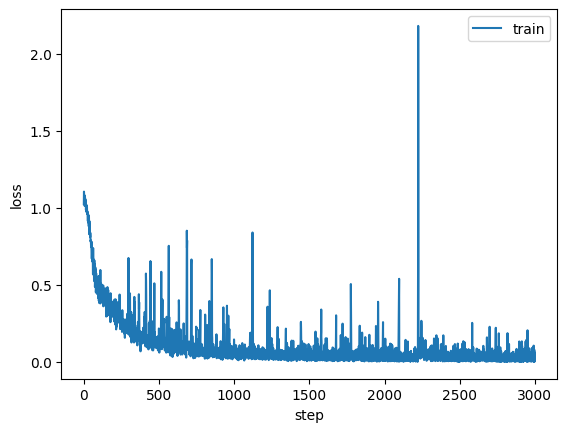

In [52]:
# TODO: 可視化コード
# ヒント: 訓練ロスをグラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する
import matplotlib.pyplot as plt

plt.plot(range(len(list_loss1)),list_loss1, label="train")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

## GPU-based computation
* Move tonsor arrays to GPU
* Move the model to GPU

In [53]:
device = torch.device("cuda:0" if torch.cuda.is_available()
                      else "cpu")

In [54]:
print(torch.cuda.is_available()) # TrueならGPU利用可能、次へ
print(torch.backends.mps.is_available()) # For mac

True
False


## Edit the code for GPU utilization
* device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
* xtrain = xtrain.to(device)
* ytrain = ytrain.to(device)
* xtest = xtest.to(device)
* ytest = ytest.to(device)
* model = MyIris().to(device)

In [55]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
xtrain = xtrain.to(device)
ytrain = ytrain.to(device)
xtest = xtest.to(device)
ytest = ytest.to(device)
model = MyIris().to(device)

In [56]:
%%time
n = 75 # data size
bs = 25 # batch size
model.train()
# TODO: lossを保存するリスト・アレイを定義
list_loss2 = []
for i in range(1000):
    idx = np.random.permutation(n)
    for j in range(0, n, bs):
        xtm = xtrain[idx[j:min(j+bs, n)]]
        ytm = ytrain[idx[j:min(j+bs, n)]]
        output = model(xtm)
        loss = criterion(output, ytm)
        if i%50 == 0:
            print('iter:', i, 'batch:', j, '->', loss.item())
        # TODO: loss.item()を保存する
        list_loss2.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

iter: 0 batch: 0 -> 1.0920524597167969
iter: 0 batch: 25 -> 1.1264959573745728
iter: 0 batch: 50 -> 1.1007122993469238
iter: 50 batch: 0 -> 1.1183114051818848
iter: 50 batch: 25 -> 1.108964443206787
iter: 50 batch: 50 -> 1.0919848680496216
iter: 100 batch: 0 -> 1.1177964210510254
iter: 100 batch: 25 -> 1.0917096138000488
iter: 100 batch: 50 -> 1.1097546815872192
iter: 150 batch: 0 -> 1.0998854637145996
iter: 150 batch: 25 -> 1.1194649934768677
iter: 150 batch: 50 -> 1.0999102592468262
iter: 200 batch: 0 -> 1.0828661918640137
iter: 200 batch: 25 -> 1.0906754732131958
iter: 200 batch: 50 -> 1.145719051361084
iter: 250 batch: 0 -> 1.0815021991729736
iter: 250 batch: 25 -> 1.1454815864562988
iter: 250 batch: 50 -> 1.0922768115997314
iter: 300 batch: 0 -> 1.0806809663772583
iter: 300 batch: 25 -> 1.1275919675827026
iter: 300 batch: 50 -> 1.110987663269043
iter: 350 batch: 0 -> 1.1260498762130737
iter: 350 batch: 25 -> 1.1201704740524292
iter: 350 batch: 50 -> 1.07304048538208
iter: 400 batc

In [57]:
model.eval()
# no grad is required to compute the test dataset without optimization
with torch.no_grad():
    output1 = model(xtest)
    ans = torch.argmax(output1, 1) # 0, 1, 2 for each
    accuracy_gpu = ((ytest == ans).sum().float() / len(ans)).item()
    print(accuracy_gpu)

0.3733333349227905


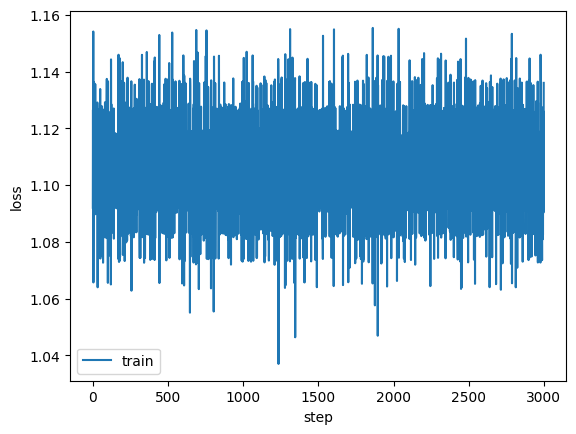

In [58]:
# TODO: 可視化コード
# ヒント: 訓練ロスをグラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する
plt.plot(range(len(list_loss2)),list_loss2, label="train")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

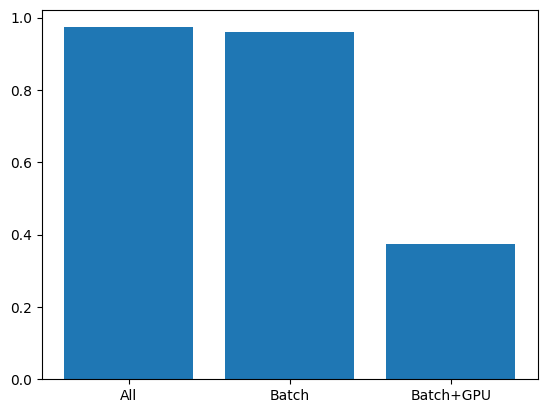

In [59]:
# TODO: 可視化コード（おまけ、必須では有りません）
# ヒント: accuracy_all, accuracy_batch, accuracy_gpuを棒グラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する
plt.bar([0, 1, 2], [accuracy_all, accuracy_batch, accuracy_gpu], tick_label=['All', 'Batch', 'Batch+GPU'])
plt.show()
